<a href="https://colab.research.google.com/github/Adityajakhar099/celebal-internship-assignments/blob/main/week3_Aditya_Jakhar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Country-data.csv')

print("Dataset Shape:", df.shape)
display(df.head())
print("\nMissing Values:\n", df.isnull().sum())

df['exports'] = (df['exports'] * df['gdpp']) / 100
df['health'] = (df['health'] * df['gdpp']) / 100
df['imports'] = (df['imports'] * df['gdpp']) / 100

print("\nData after converting percentages to absolute values:")
display(df.head())

Dataset Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200



Missing Values:
 country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Data after converting percentages to absolute values:


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,55.30,41.9174,248.297,1610,9.44,56.2,5.82,553
1,Albania,16.6,1145.20,267.8950,1987.740,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,1712.64,185.9820,1400.440,12900,16.10,76.5,2.89,4460
3,Angola,119.0,2199.19,100.6050,1514.370,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,5551.00,735.6600,7185.800,19100,1.44,76.8,2.13,12200


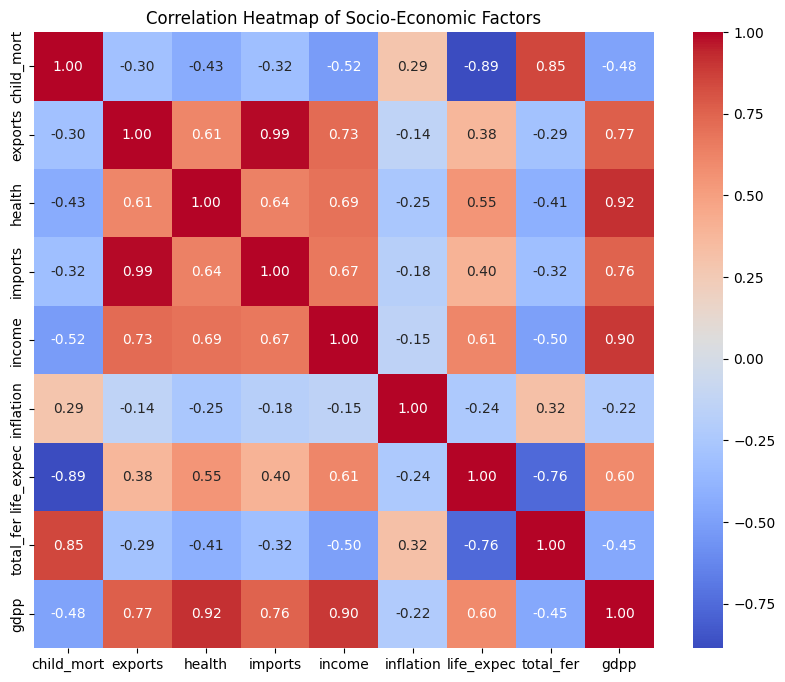

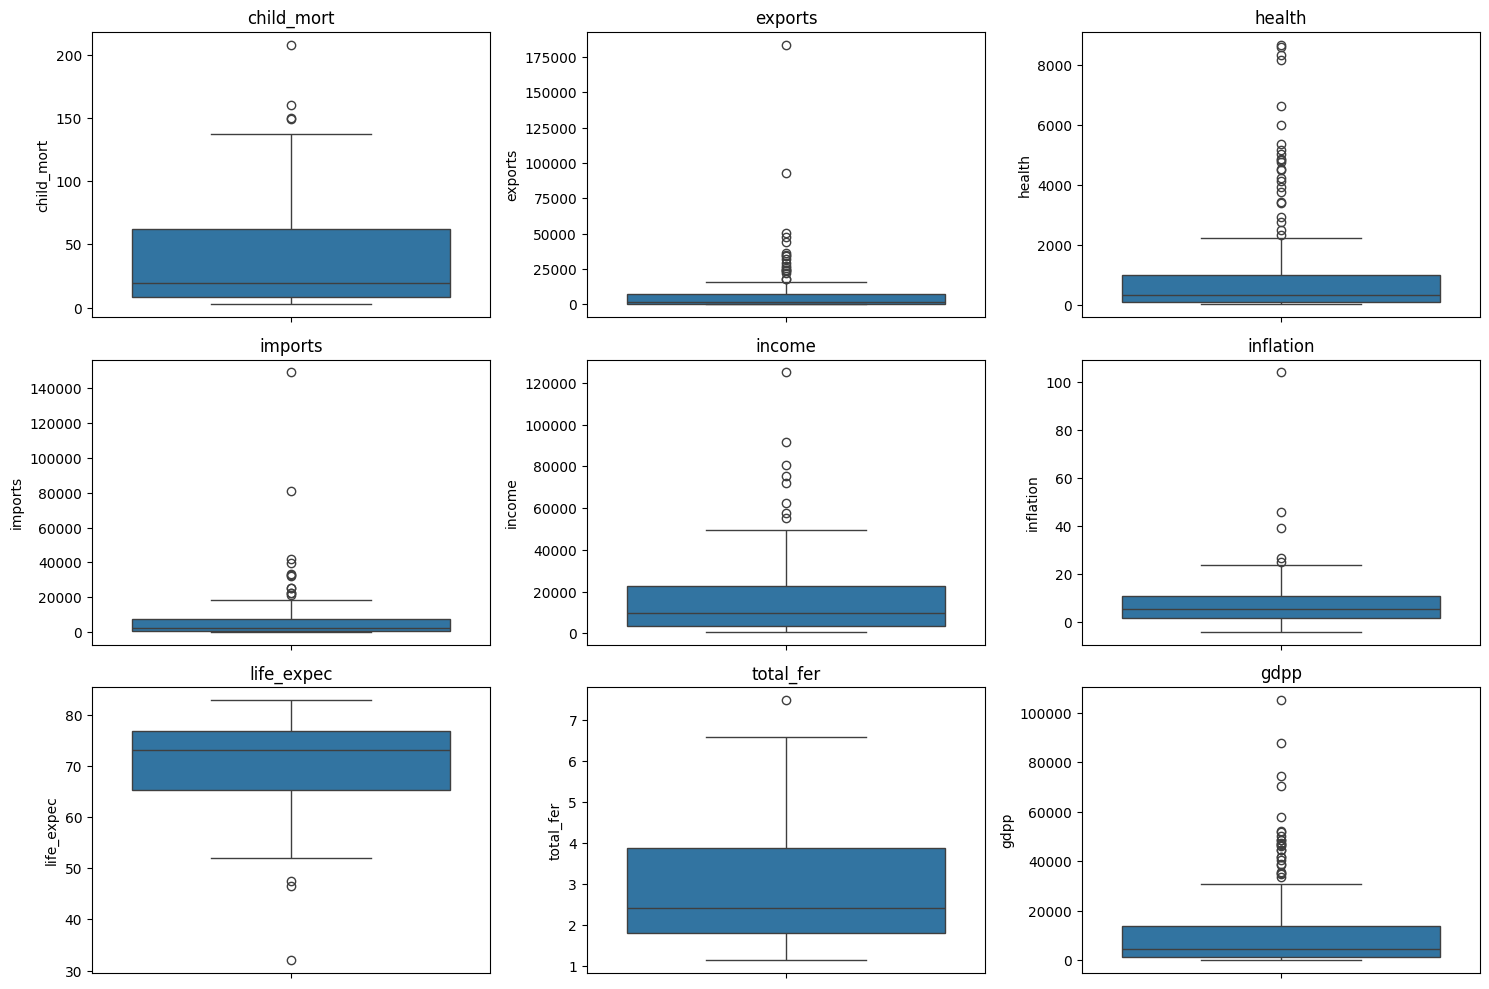

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Socio-Economic Factors')
plt.show()

features = ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']
plt.figure(figsize=(15, 10))
for i, feature in enumerate(features):
    plt.subplot(3, 3, i+1)
    sns.boxplot(y=df[feature])
    plt.title(feature)
plt.tight_layout()
plt.show()

q1 = df['gdpp'].quantile(0.95)
df['gdpp'][df['gdpp'] >= q1] = q1

q2 = df['income'].quantile(0.95)
df['income'][df['income'] >= q2] = q2

q3 = df['exports'].quantile(0.95)
df['exports'][df['exports'] >= q3] = q3

In [ ]:
from sklearn.preprocessing import StandardScaler

X = df.drop('country', axis=1)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

display(X_scaled_df.head())

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-0.669581,-0.565040,-0.432276,-0.958349,0.157336,-1.619092,1.902882,-0.757362
1,-0.538949,-0.542172,-0.439218,-0.313677,-0.394006,-0.312347,0.647866,-0.859973,-0.523321
2,-0.272833,-0.475838,-0.484826,-0.353720,-0.192552,0.789274,0.670423,-0.038404,-0.498838
3,2.007808,-0.418960,-0.532363,-0.345953,-0.667360,1.387054,-1.179234,2.128151,-0.560376
4,-0.695634,-0.027134,-0.178771,0.040735,0.227992,-0.601749,0.704258,-0.541946,0.013312


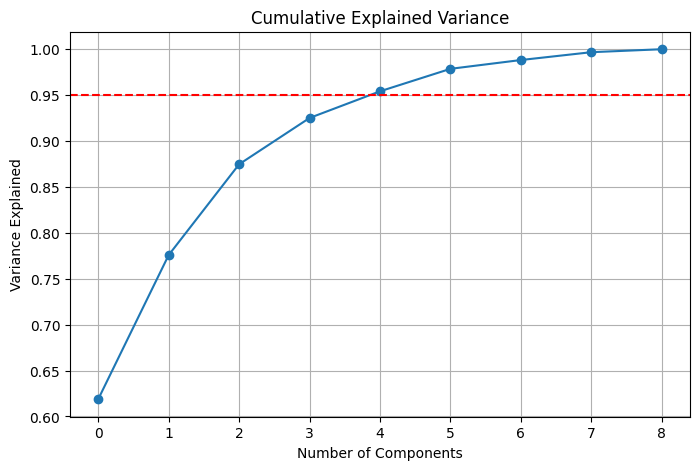

Shape of PCA data: (167, 4)


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(random_state=42)
pca.fit(X_scaled)

plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.axhline(y=0.95, color='r', linestyle='--')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Variance Explained')
plt.grid(True)
plt.show()

pca_final = PCA(n_components=4, random_state=42)
X_pca = pca_final.fit_transform(X_scaled)

print("Shape of PCA data:", X_pca.shape)

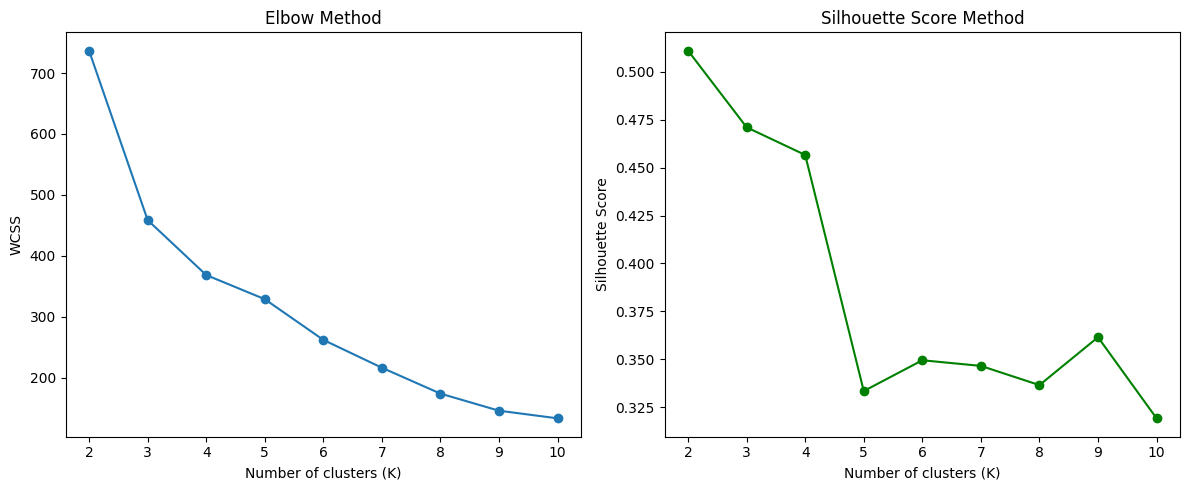

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

wcss = []
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, kmeans.labels_))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(2, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS')

plt.subplot(1, 2, 2)
plt.plot(range(2, 11), silhouette_scores, marker='o', color='green')
plt.title('Silhouette Score Method')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

,gdpp,child_mort,income
Cluster_ID,,,
0,6388.952381,21.951190,12462.976190
1,38333.055556,5.188889,39086.388889
2,1854.085106,92.774468,3710.063830


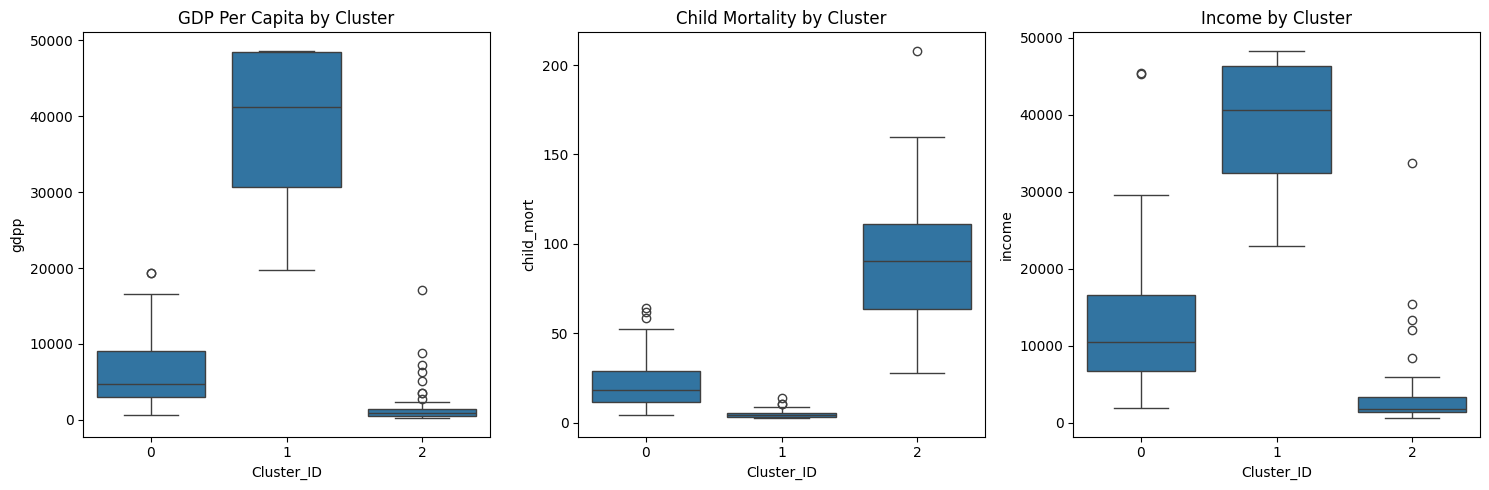

In [ ]:
kmeans_final = KMeans(n_clusters=3, random_state=42)
kmeans_final.fit(X_pca)

df['Cluster_ID'] = kmeans_final.labels_

cluster_profile = df[['gdpp', 'child_mort', 'income', 'Cluster_ID']].groupby('Cluster_ID').mean()
display(cluster_profile)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.boxplot(x='Cluster_ID', y='gdpp', data=df)
plt.title('GDP Per Capita by Cluster')

plt.subplot(1, 3, 2)
sns.boxplot(x='Cluster_ID', y='child_mort', data=df)
plt.title('Child Mortality by Cluster')

plt.subplot(1, 3, 3)
sns.boxplot(x='Cluster_ID', y='income', data=df)
plt.title('Income by Cluster')
plt.tight_layout()
plt.show()

In [ ]:
target_cluster_id = 0

dire_need_countries = df[df['Cluster_ID'] == target_cluster_id]

top_priority_countries = dire_need_countries.sort_values(
    by=['child_mort', 'gdpp', 'income'],
    ascending=[False, True, True]
)

print("\n--- FINAL RECOMMENDATION FOR HELP INTERNATIONAL CEO ---")
print("Top 10 countries in the direst need of aid:\n")
display(top_priority_countries[['country', 'child_mort', 'gdpp', 'income']].head(10))


--- FINAL RECOMMENDATION FOR HELP INTERNATIONAL CEO ---
Top 10 countries in the direst need of aid:



,country,child_mort,gdpp,income
107,Myanmar,64.4,988,3720.0
154,Turkmenistan,62.0,4440,9940.0
69,India,58.8,1350,4410.0
146,Tajikistan,52.4,738,2110.0
12,Bangladesh,49.4,758,2440.0
109,Nepal,47.0,592,1990.0
19,Bolivia,46.6,1980,5410.0
27,Cambodia,44.4,786,2520.0
18,Bhutan,42.7,2180,6420.0
101,"Micronesia, Fed. Sts.",40.0,2860,3340.0


In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score

dbscan = DBSCAN(eps=1.5, min_samples=3)
dbscan_labels = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = dbscan_labels

kmeans_silhouette = silhouette_score(X_scaled, kmeans_final.labels_)

if len(set(dbscan_labels)) > 1:
    dbscan_silhouette = silhouette_score(X_scaled, dbscan_labels)
else:
    dbscan_silhouette = -1

kmeans_db_index = davies_bouldin_score(X_scaled, kmeans_final.labels_)
if len(set(dbscan_labels)) > 1:
    dbscan_db_index = davies_bouldin_score(X_scaled, dbscan_labels)
else:
    dbscan_db_index = 999

print("--- CLUSTERING PERFORMANCE ---")
print(f"K-Means Silhouette Score: {kmeans_silhouette:.4f} | Davies-Bouldin: {kmeans_db_index:.4f}")
print(f"DBSCAN Silhouette Score: {dbscan_silhouette:.4f} | Davies-Bouldin: {dbscan_db_index:.4f}")


--- CLUSTERING PERFORMANCE ---
K-Means Silhouette Score: 0.4173 | Davies-Bouldin: 0.8548
DBSCAN Silhouette Score: 0.2761 | Davies-Bouldin: 2.4079


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X_trees = df.drop(['country', 'Cluster_ID', 'DBSCAN_Cluster'], axis=1)
y_trees = df['Cluster_ID']

X_train, X_test, y_train, y_test = train_test_split(X_trees, y_trees, test_size=0.3, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)

rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test)

In [ ]:
print("--- RANDOM FOREST PERFORMANCE ---")
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.4f}")
print("Classification Report:\n", classification_report(y_test, rf_preds))

print("\n--- XGBOOST PERFORMANCE ---")
print(f"Accuracy: {accuracy_score(y_test, xgb_preds):.4f}")
print("Classification Report:\n", classification_report(y_test, xgb_preds))

--- RANDOM FOREST PERFORMANCE ---
Accuracy: 0.9804
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98        29
           1       1.00      1.00      1.00        11
           2       1.00      0.91      0.95        11

    accuracy                           0.98        51
   macro avg       0.99      0.97      0.98        51
weighted avg       0.98      0.98      0.98        51


--- XGBOOST PERFORMANCE ---
Accuracy: 0.9804
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98        29
           1       1.00      1.00      1.00        11
           2       1.00      0.91      0.95        11

    accuracy                           0.98        51
   macro avg       0.99      0.97      0.98        51
weighted avg       0.98      0.98      0.98        51



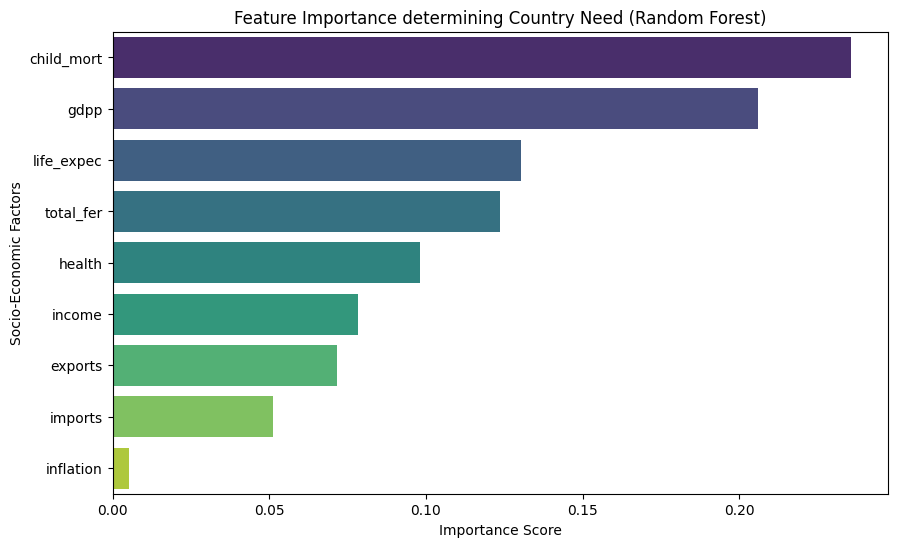

In [ ]:
feature_importances = pd.Series(rf_model.feature_importances_, index=X_trees.columns)
feature_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_importances.index, palette='viridis')
plt.title('Feature Importance determining Country Need (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Socio-Economic Factors')
plt.show()